# Quick visualization with `quick_visualize_Q()`

This notebook introduces `nematics3d.quick_visualize_Q()`, a convenience function for getting a first look at a 3D nematic field.

We will use the bundled example file `example/data/Q_example_workflow.npy` and focus on three goals:

- load a sample Q-tensor field
- generate one quick combined visualization
- understand the most important arguments to tweak first


## What `quick_visualize_Q()` is for

The main purpose of `quick_visualize_Q()` is to give you a fast and useful first visualization of a 3D director field with very little code.

It is meant for the stage where you have field data already, and you want to answer questions like these as quickly as possible:

- What does the global defect structure look like?
- Where are the main disclination lines?
- If I want to inspect this dataset further, where should I look next?

So this function is best treated as a first-pass overview tool. It helps you get an initial picture before moving on to more detailed and manually controlled workflows.

Internally, it does several things for you in one call:

- builds a `QFieldObject`
- detects defects and classifies disclination lines during initialization
- automatically chooses several visualization scales from the field size
- optionally smooths and plots disclination lines
- adds one director plane through the middle of the sample
- returns both the `QFieldObject` and the `PlotFigure`


## Setup

**For readers who are only interested in the tutorial, this section can be safely skipped.** The next two code cells only do setup work. They import the package and helper modules, locate the repository root, load the bundled example data, and create an output folder for this tutorial. This notebook writes its generated images into its own dedicated subfolder under `tutorials/output/quick_visualize_Q`.

In [1]:
from pathlib import Path
import sys

import numpy as np
from IPython.display import Image, display


def find_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "example" / "data" / "Q_example_workflow.npy").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()

try:
    import nematics3d
except ModuleNotFoundError:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    import nematics3d

DATA_PATH = REPO_ROOT / "example" / "data" / "Q_example_workflow.npy"
OUTPUT_DIR = REPO_ROOT / "tutorials" / "output" / "quick_visualize_Q"
EXAMPLE_IMAGE_PATH = REPO_ROOT / "tutorials" / "output" / "interact_with_figures" / "example.png"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data file: {DATA_PATH}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Example image: {EXAMPLE_IMAGE_PATH}")


Repository root: D:\Document\GitHub\Nematics3D
Data file: D:\Document\GitHub\Nematics3D\example\data\Q_example_workflow.npy
Output folder: D:\Document\GitHub\Nematics3D\tutorials\output\quick_visualize_Q
Example image: D:\Document\GitHub\Nematics3D\tutorials\output\interact_with_figures\example.png


In [2]:
Q_data = np.load(DATA_PATH)
Q_data.shape


(200, 100, 100, 5)

## Minimal example

We start with the default interactive style, because that is the most natural way to use `quick_visualize_Q` when you are exploring a dataset for the first time.

The input here is intentionally minimal. We pass only one argument:

- `Q=Q_data`: the Q-tensor field loaded from the example file

Everything else is left at its default value, so that you can see the shortest useful call first.

In [3]:
Q_obj, figure = nematics3d.quick_visualize_Q(
    Q=Q_data,
)


[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `Q`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `Q` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='Q'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='Q'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.63 s
[INFO]
        <QFieldObject[name='Q'].act_lines_smooth> 
        There are 8 disclination lines in total, with 7 lines are smoothed.
        The smoothing window length is: 41


A typical result is shown below. The exact window layout, toolbar placement, menu-bar appearance, and font rendering may vary across local environments, but the main plotted content should look similar.

![Example interactive figure](output/interact_with_figures/example.png)


A few things happened in that single call:

- `QFieldObject` was created from the input Q tensor
- defects were detected and grouped into disclination lines
- the lines were smoothed and visualized
- a director plane was inserted through the middle of the volume
- an interactive figure window was created

For a first-pass inspection, this is often enough to answer: *What is the global defect structure, and where should I look next?*

At this stage, you can rotate the view, inspect the plotted objects, and decide which regions deserve a closer look.

## What is returned

The function returns two objects:

- `Q_obj`: the underlying `QFieldObject`
- `figure`: the `PlotFigure` used for rendering

That means `quick_visualize_Q()` is not a dead-end helper. You can use it as a fast entry point, then continue with the returned objects for more detailed work.

## What is the next step?

The most direct next step is often to interact with this figure and inspect the part of the system that looks interesting to you.

For example, after getting this first overview, you might want to:

- rotate the camera and identify the main defect structures
- click or inspect plotted objects to understand which line or region you are looking at
- decide which local area deserves a more focused follow-up plot

This work flow is covered in [interact_with_figures.ipynb](./interact_with_figures.ipynb).

## Arguments

| Argument | What it controls | Typical form |
| --- | --- | --- |
| `Q` | Input Q-tensor field | Usually a NumPy array with shape `(Nx, Ny, Nz, 5)` or `(Nx, Ny, Nz, 9)` |
| `S` and `n` | Alternative way to build the field | `S`: `(Nx, Ny, Nz)` and `n`: `(Nx, Ny, Nz, 3)`, on the same grid |
| `grid_normal` | Orientation of the director plane | A 3D vector such as `(0, 0, 1)` or `(1, 1, 0)` |
| `is_visualize_lines` | Whether to draw smoothed lines or raw defect points | `True` or `False` |
| `box_periodic_flag` | Periodic boundary condition of the box | Either one boolean like `True`, or three booleans like `(True, False, False)` for x, y, z |
| `save_path` and `is_off_screen` | Whether to save an image without opening a visible window | For example `save_path=...` together with `is_off_screen=True` |

If you want the full input conventions for `Q`, `S`, and `n`, see [build_QFieldObject.ipynb](./build_QFieldObject.ipynb).


## Example: change the director plane orientation

By default, the director plane is normal to `(0, 0, 1)`. If you want a different slice through the system, `grid_normal` is the first thing to try.

[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `workflow_Q_tilted_plane`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `workflow_Q_tilted_plane` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='workflow_Q_tilted_plane'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='workflow_Q_tilted_plane'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.32 s
[INFO]
        <QFieldObject[name='workflow_Q_tilted_plane'].act_lines_smooth> 
        There are 8 disclination lines in total, with 7 lines are smoothed.
        The smoothing window length is: 41

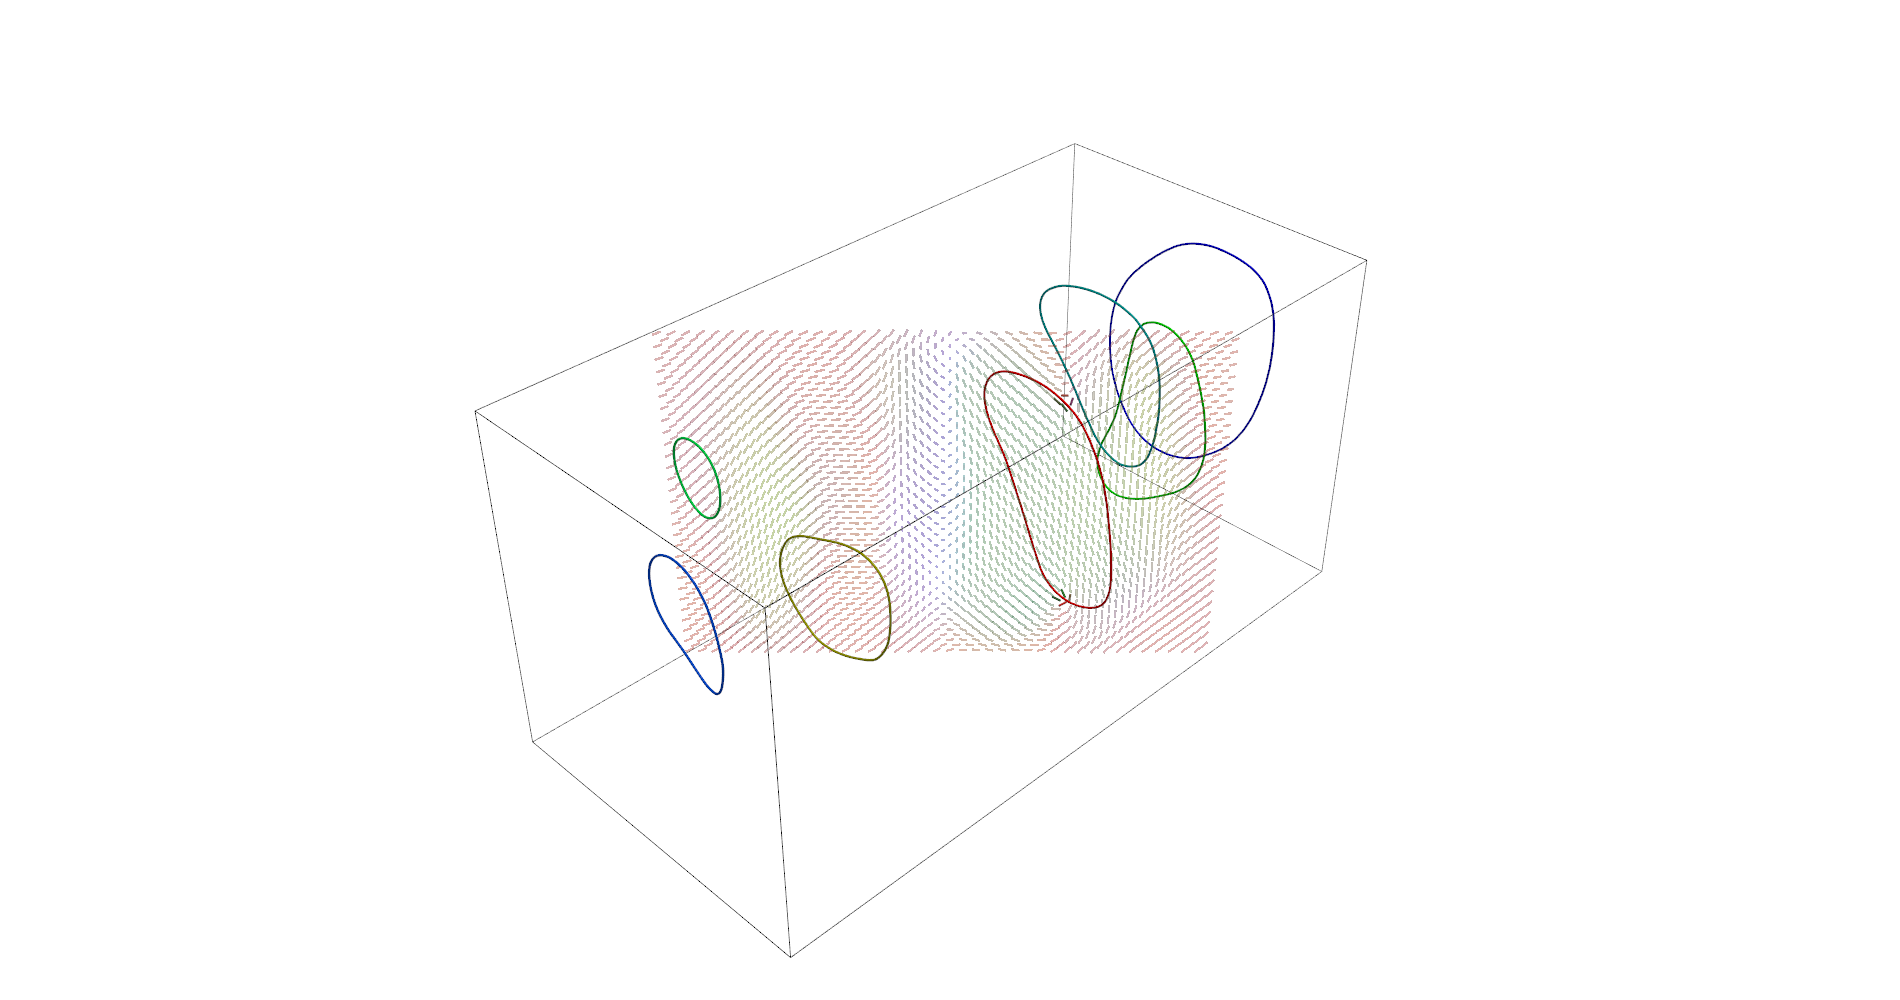

In [4]:
save_path_tilted = OUTPUT_DIR / "tilted_plane.png"

Q_obj_tilted, figure_tilted = nematics3d.quick_visualize_Q(
    Q=Q_data,
    name="workflow_Q_tilted_plane",
    grid_normal=(1, 1, 0),
    save_path=save_path_tilted,
    is_off_screen=True,
)

display(Image(filename=save_path_tilted)) # display the off-screen figure saved by previous command


## Example: show defect points instead of disclination lines

If you set `is_visualize_lines=False`, the function skips line visualization and shows the detected defect points directly. This can be useful when you want to inspect the raw detected structure before the smoothed line representation.

[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `workflow_Q_points`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `workflow_Q_points` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='workflow_Q_points'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='workflow_Q_points'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.37 s


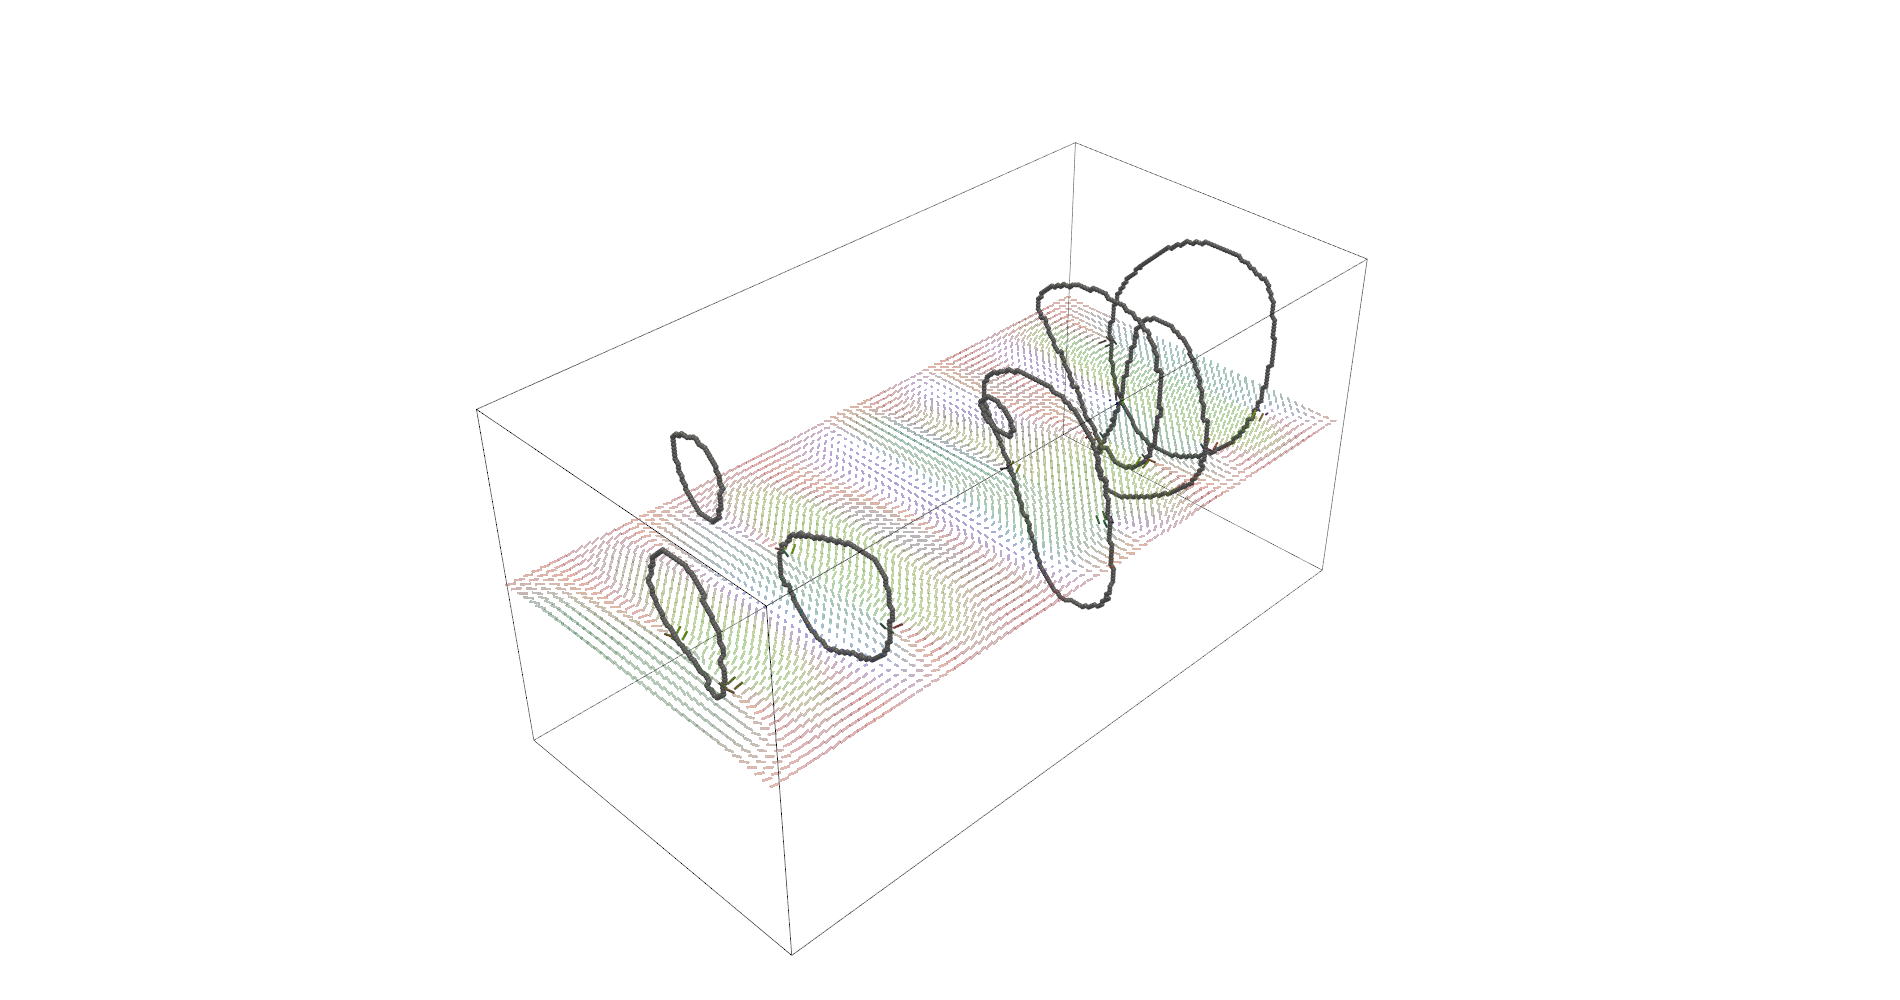

In [5]:
save_path_points = OUTPUT_DIR / "defect_points.png"

Q_obj_points, figure_points = nematics3d.quick_visualize_Q(
    Q=Q_data,
    name="workflow_Q_points",
    is_visualize_lines=False,
    save_path=save_path_points,
    is_off_screen=True,
)

display(Image(filename=save_path_points)) # display the off-screen figure saved by previous command


## About off-screen output

Several later examples in this notebook already use off-screen rendering. The basic idea is simple: provide a `save_path`, set `is_off_screen=True`, and then display the saved image if you want it inline.

## Summary

In this notebook, we used `quick_visualize_Q` as a compact entry point for visualizing a 3D Q-tensor field. The function is especially useful because it gives a meaningful overview in one call, while still returning the full `QFieldObject` and `PlotFigure` for later analysis.

## Useful Links